In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

maintenance = pd.read_csv("../data/raw/maintenance.csv")

print("Maintenance shape:", maintenance.shape)
display(maintenance.head())

Maintenance shape: (6, 14)


,task_id,asset_id,section_id,department,maintenance_type,defect_type,severity,criticality,created_date,due_date,overdue_days,estimated_duration,required_manpower,status
0,TMS001,TRK001,NDL-MTJ-01,ENGINEERING,REPAIR,RAIL_CRACK,9,10,2026-08-20,2026-09-01,1,90,8,PENDING
1,TMS002,TRK002,NDL-MTJ-02,ENGINEERING,INSPECTION,TRACK_WEAR,4,8,2026-08-25,2026-09-10,0,60,5,PENDING
2,SMMS001,SIG001,MTJ-AGC-01,S&T,REPAIR,SIGNAL_DEGRADATION,8,9,2026-08-22,2026-09-04,0,45,3,PENDING
3,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,SIGNAL_CHECK,3,7,2026-08-28,2026-09-15,0,30,2,PENDING
4,TDMS001,OHE001,GWL-JHS-01,TRACTION,REPAIR,OHE_INSULATOR,7,9,2026-08-18,2026-09-03,0,60,5,PENDING


In [2]:
np.random.seed(42)

maintenance["severity"] = pd.to_numeric(
    maintenance["severity"], errors="coerce"
).fillna(0)

maintenance["criticality"] = pd.to_numeric(
    maintenance["criticality"], errors="coerce"
).fillna(0)

maintenance["overdue_days"] = pd.to_numeric(
    maintenance["overdue_days"], errors="coerce"
).fillna(0)

maintenance["estimated_duration"] = pd.to_numeric(
    maintenance["estimated_duration"], errors="coerce"
).fillna(
    maintenance["estimated_duration"].median()
)

maintenance["required_manpower"] = pd.to_numeric(
    maintenance["required_manpower"], errors="coerce"
).fillna(
    maintenance["required_manpower"].median()
)

In [3]:
severity_factor = 1 + 0.02 * maintenance["severity"]

criticality_factor = 1 + 0.015 * maintenance["criticality"]

manpower_factor = 1 + 0.03 * np.maximum(
    maintenance["required_manpower"] - 2, 0
)

overdue_factor = 1 + 0.005 * np.minimum(
    maintenance["overdue_days"], 30
)

noise_factor = np.random.normal(
    loc=1.0,
    scale=0.12,
    size=len(maintenance)
)

maintenance["actual_duration"] = (
    maintenance["estimated_duration"]
    * severity_factor
    * criticality_factor
    * manpower_factor
    * overdue_factor
    * noise_factor
)

In [4]:
maintenance["actual_duration"] = maintenance[
    "actual_duration"
].clip(lower=15)

maintenance["actual_duration"] = (
    maintenance["actual_duration"].round(1)
)

display(
    maintenance[
        [
            "task_id",
            "severity",
            "criticality",
            "estimated_duration",
            "required_manpower",
            "overdue_days",
            "actual_duration"
        ]
    ].head(20)
)

,task_id,severity,criticality,estimated_duration,required_manpower,overdue_days,actual_duration
0,TMS001,9,10,90,8,1,153.5
1,TMS002,4,8,60,5,0,77.8
2,SMMS001,8,9,45,3,0,65.8
3,SMMS002,3,7,30,2,0,41.6
4,TDMS001,7,9,60,5,0,82.2
5,TDMS002,3,8,45,4,0,55.0


In [5]:
print(
    maintenance[
        [
            "estimated_duration",
            "severity",
            "criticality",
            "overdue_days",
            "required_manpower",
            "actual_duration"
        ]
    ].corr()["actual_duration"].sort_values(ascending=False)
)

actual_duration       1.000000
estimated_duration    0.975300
required_manpower     0.950630
overdue_days          0.925466
criticality           0.851992
severity              0.742472
Name: actual_duration, dtype: float64


In [6]:
import matplotlib.pyplot as plt

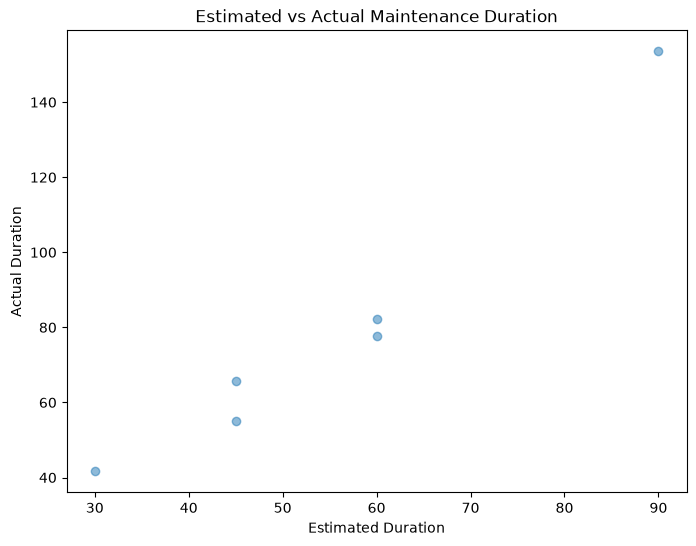

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    maintenance["estimated_duration"],
    maintenance["actual_duration"],
    alpha=0.5
)

plt.xlabel("Estimated Duration")
plt.ylabel("Actual Duration")
plt.title("Estimated vs Actual Maintenance Duration")

plt.show()

In [8]:
duration_features = [
    "estimated_duration",
    "severity",
    "criticality",
    "overdue_days",
    "required_manpower"
]

duration_target = "actual_duration"

X_duration = maintenance[duration_features]
y_duration = maintenance[duration_target]

print("Features:")
print(duration_features)

print("\nTarget:")
print(duration_target)

print("\nDataset shape:")
print(X_duration.shape)

Features:
['estimated_duration', 'severity', 'criticality', 'overdue_days', 'required_manpower']

Target:
actual_duration

Dataset shape:
(6, 5)


In [9]:
maintenance["created_date"] = pd.to_datetime(
    maintenance["created_date"]
)

maintenance = maintenance.sort_values(
    "created_date"
).reset_index(drop=True)

split_date = maintenance["created_date"].quantile(0.80)

train_duration = maintenance[
    maintenance["created_date"] < split_date
].copy()

test_duration = maintenance[
    maintenance["created_date"] >= split_date
].copy()

print("Training rows:", len(train_duration))
print("Testing rows:", len(test_duration))
print("Split date:", split_date)

Training rows: 4
Testing rows: 2
Split date: 2026-08-28 00:00:00


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train_duration = train_duration[duration_features]
y_train_duration = train_duration[duration_target]

X_test_duration = test_duration[duration_features]
y_test_duration = test_duration[duration_target]

duration_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

duration_model.fit(
    X_train_duration,
    y_train_duration
)

duration_predictions = duration_model.predict(
    X_test_duration
)

print("Duration model trained successfully.")

Duration model trained successfully.


In [11]:
mae = mean_absolute_error(
    y_test_duration,
    duration_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_duration,
        duration_predictions
    )
)

r2 = r2_score(
    y_test_duration,
    duration_predictions
)

print("Maintenance Duration Model")
print("--------------------------")
print("MAE :", round(mae, 2), "minutes")
print("RMSE:", round(rmse, 2), "minutes")
print("R²  :", round(r2, 3))

Maintenance Duration Model
--------------------------
MAE : 47.48 minutes
RMSE: 47.95 minutes
R²  : -50.214


In [12]:
mae = mean_absolute_error(
    y_test_duration,
    duration_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_duration,
        duration_predictions
    )
)

r2 = r2_score(
    y_test_duration,
    duration_predictions
)

print("Maintenance Duration Model")
print("--------------------------")
print("MAE :", round(mae, 2), "minutes")
print("RMSE:", round(rmse, 2), "minutes")
print("R²  :", round(r2, 3))

Maintenance Duration Model
--------------------------
MAE : 47.48 minutes
RMSE: 47.95 minutes
R²  : -50.214


In [13]:
baseline_predictions = test_duration["estimated_duration"]

baseline_mae = mean_absolute_error(
    y_test_duration,
    baseline_predictions
)

model_mae = mean_absolute_error(
    y_test_duration,
    duration_predictions
)

print("Existing estimate MAE:", round(baseline_mae, 2), "minutes")
print("ML model MAE:", round(model_mae, 2), "minutes")

Existing estimate MAE: 10.8 minutes
ML model MAE: 47.48 minutes


In [14]:
improvement = (
    (baseline_mae - model_mae)
    / baseline_mae
) * 100

print("MAE improvement:", round(improvement, 2), "%")

MAE improvement: -339.61 %


In [15]:
duration_results = test_duration[
    [
        "task_id",
        "asset_id",
        "section_id",
        "department",
        "maintenance_type",
        "estimated_duration",
        "severity",
        "criticality",
        "required_manpower",
        "actual_duration"
    ]
].copy()

duration_results["predicted_duration"] = duration_predictions

duration_results["duration_error"] = (
    duration_results["predicted_duration"]
    - duration_results["actual_duration"]
)

display(duration_results.head(20))

,task_id,asset_id,section_id,department,maintenance_type,estimated_duration,severity,criticality,required_manpower,actual_duration,predicted_duration,duration_error
4,SMMS002,SIG002,AGC-GWL-01,S&T,INSPECTION,30,3,7,2,41.6,95.777417,54.177417
5,TDMS002,OHE002,JHS-BINA-01,TRACTION,INSPECTION,45,3,8,4,55.0,95.777417,40.777417


In [16]:
duration_results.to_csv(
    "../data/predictions/maintenance_duration_predictions.csv",
    index=False
)

print(
    "Saved:",
    "../data/predictions/maintenance_duration_predictions.csv"
)

Saved: ../data/predictions/maintenance_duration_predictions.csv
